# Appendix 1: Code and Output

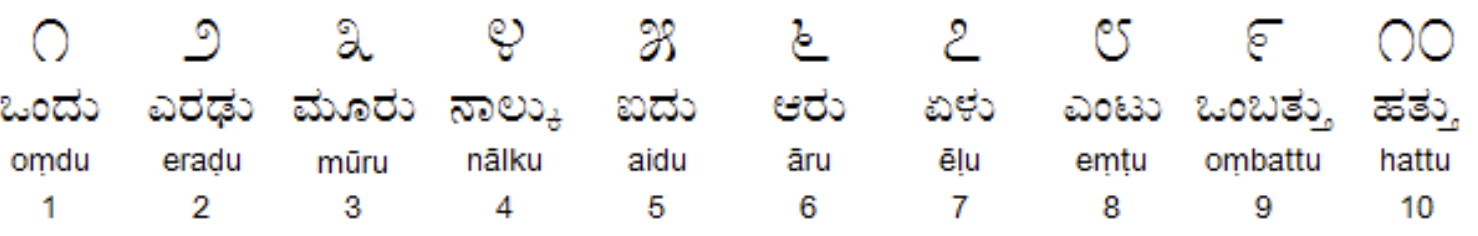

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Time libraries
import time
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

## 1. EXPLORATORY DATA ANALYSIS

### 1.1 Shape and Features 

In [2]:
# Load the data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
id_values = test_data['id']
test_data = test_data.drop('id', axis=1)

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Training data shape: (60000, 785)
Test data shape: (5000, 784)


In [3]:
# Separate features and labels
X_train = train_data.drop('label', axis=1)
y_train = train_data['label']
X_test = test_data


print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test features shape: {X_test.shape}")

# Basic info about the dataset
print(f"\nFeature columns: {X_train.columns.tolist()[:10]}..." if len(X_train.columns) > 10 else f"\nFeature columns: {X_train.columns.tolist()}")
print(f"Data types: {X_train.dtypes.value_counts().to_dict()}")

Training features shape: (60000, 784)
Training labels shape: (60000,)
Test features shape: (5000, 784)

Feature columns: ['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9']...
Data types: {dtype('int64'): 784}


### 1.2 Analyzing Target Distribution

In [4]:
# Count of each digit
label_counts = y_train.value_counts().sort_index()
print("Label distribution:")
for label, count in label_counts.items():
    percentage = (count / len(y_train)) * 100
    print(f"Digit {label}: {count:,} samples ({percentage:.2f}%)")

# Check for class imbalance
print(f"\nClass balance analysis:")
print(f"Most common class: {label_counts.max():,} samples")
print(f"Least common class: {label_counts.min():,} samples")
print(f"Balance ratio: {label_counts.max() / label_counts.min():.2f}:1")

Label distribution:
Digit 0: 6,000 samples (10.00%)
Digit 1: 6,000 samples (10.00%)
Digit 2: 6,000 samples (10.00%)
Digit 3: 6,000 samples (10.00%)
Digit 4: 6,000 samples (10.00%)
Digit 5: 6,000 samples (10.00%)
Digit 6: 6,000 samples (10.00%)
Digit 7: 6,000 samples (10.00%)
Digit 8: 6,000 samples (10.00%)
Digit 9: 6,000 samples (10.00%)

Class balance analysis:
Most common class: 6,000 samples
Least common class: 6,000 samples
Balance ratio: 1.00:1


### 1.3 Descriptive Statistics

In [5]:
print("Basic statistics for pixel values (first 5 features):")
print(X_train.iloc[:, :5].describe())

print(f"\nOverall pixel value statistics:")
print(f"Min pixel value: {X_train.min().min()}")
print(f"Max pixel value: {X_train.max().max()}")
print(f"Mean pixel value: {X_train.mean().mean():.2f}")
print(f"Std pixel value: {X_train.std().mean():.2f}")

Basic statistics for pixel values (first 5 features):
        pixel0   pixel1   pixel2   pixel3   pixel4
count  60000.0  60000.0  60000.0  60000.0  60000.0
mean       0.0      0.0      0.0      0.0      0.0
std        0.0      0.0      0.0      0.0      0.0
min        0.0      0.0      0.0      0.0      0.0
25%        0.0      0.0      0.0      0.0      0.0
50%        0.0      0.0      0.0      0.0      0.0
75%        0.0      0.0      0.0      0.0      0.0
max        0.0      0.0      0.0      0.0      0.0

Overall pixel value statistics:
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 20.99
Std pixel value: 42.25


In [6]:
# Check for missing values
print(f"\nMissing values in training data: {train_data.isnull().sum().sum()}")
print(f"Missing values in test data: {test_data.isnull().sum().sum()}")


Missing values in training data: 0
Missing values in test data: 0


In [7]:
# Check for constant features (zero variance)
zero_var_features = (X_train.var() == 0).sum()
print(f"Features with zero variance: {zero_var_features}")

Features with zero variance: 75


In [8]:
# Since we know this is 784 features (28x28 pixel images), let's confirm
expected_features = 784  # 28x28 = 784
if X_train.shape[1] == expected_features:
    print(f"Confirmed: Dataset has {expected_features} features (28x28 pixel images)")
    image_height, image_width = 28, 28
else:
    print(f"Unexpected number of features: {X_train.shape[1]} (expected {expected_features})")
    # Try to infer dimensions
    import math
    sqrt_features = int(math.sqrt(X_train.shape[1]))
    if sqrt_features * sqrt_features == X_train.shape[1]:
        image_height = image_width = sqrt_features
        print(f"  Inferred image dimensions: {image_height}x{image_width}")
    else:
        image_height = image_width = 28  # Default assumption

Confirmed: Dataset has 784 features (28x28 pixel images)


### 1.4 Visualization

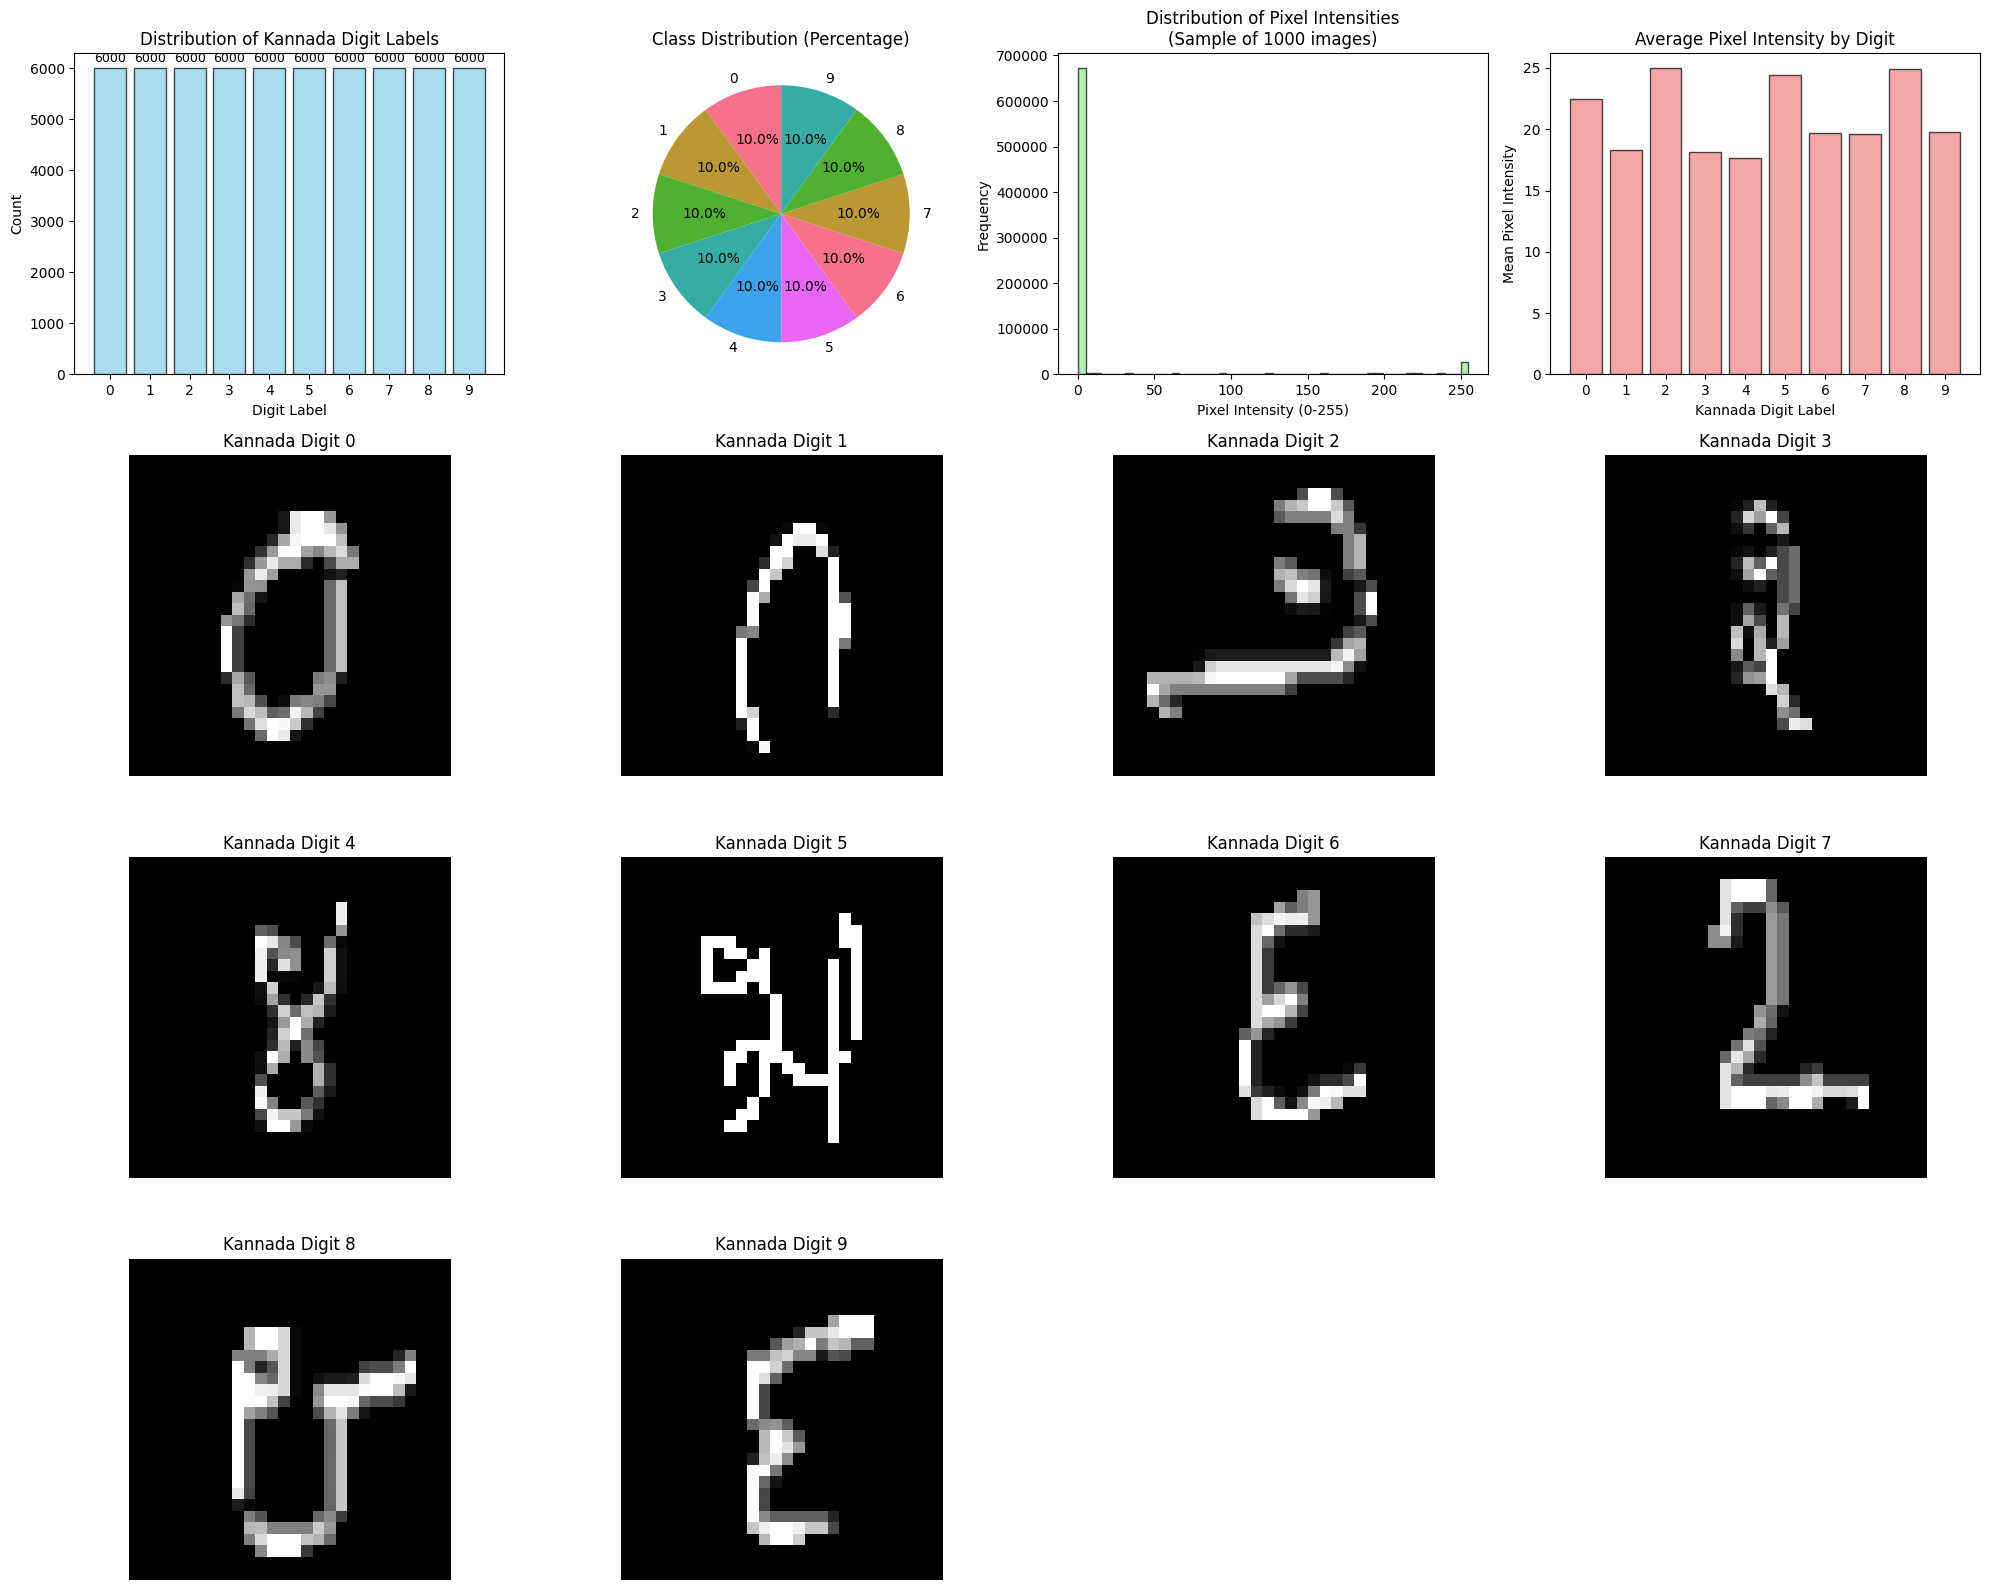

In [9]:
# Create a comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# Plot 1: Label Distribution
plt.subplot(4, 4, 1)
bars = plt.bar(label_counts.index, label_counts.values, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Digit Label')
plt.ylabel('Count')
plt.title('Distribution of Kannada Digit Labels')
plt.xticks(range(10))
# Add count labels on bars
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(label_counts.values)*0.01, 
             str(count), ha='center', va='bottom', fontsize=9)

# Plot 2: Class Imbalance Visualization
plt.subplot(4, 4, 2)
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution (Percentage)')

# Plot 3: Pixel Intensity Distribution
plt.subplot(4, 4, 3)
sample_pixels = X_train.iloc[:1000].values.flatten()  # Sample for efficiency
plt.hist(sample_pixels, bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.title('Distribution of Pixel Intensities\n(Sample of 1000 images)')

# Plot 4: Mean pixel intensity by digit
plt.subplot(4, 4, 4)
mean_intensities = []
for digit in range(10):
    digit_data = X_train[y_train == digit]
    if len(digit_data) > 0:
        mean_intensities.append(digit_data.mean().mean())
    else:
        mean_intensities.append(0)

plt.bar(range(10), mean_intensities, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('Kannada Digit Label')
plt.ylabel('Mean Pixel Intensity')
plt.title('Average Pixel Intensity by Digit')
plt.xticks(range(10))

# Plots 5-12: Sample images for each digit
for i in range(10):
    plt.subplot(4, 4, i + 5)
    # Find first occurrence of digit i
    digit_indices = y_train[y_train == i].index
    if len(digit_indices) > 0:
        digit_idx = digit_indices[0]
        image = X_train.iloc[digit_idx].values.reshape(image_height, image_width)
        plt.imshow(image, cmap='gray', vmin=0, vmax=255)
        plt.title(f'Kannada Digit {i}')
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, f'No samples\nfor digit {i}', ha='center', va='center')
        plt.title(f'Kannada Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

### 1.5 Analyzing Pixels

In [10]:
# Calculate variance for each pixel position
pixel_variances = X_train.var()
print(f"Pixel variance statistics:")
print(f"Mean variance: {pixel_variances.mean():.4f}")
print(f"Std variance: {pixel_variances.std():.4f}")
print(f"Min variance: {pixel_variances.min():.4f}")
print(f"Max variance: {pixel_variances.max():.4f}")

# Find most and least informative pixels
most_informative_pixels = pixel_variances.nlargest(10)
least_informative_pixels = pixel_variances.nsmallest(10)

print(f"\nTop 10 most informative pixels (highest variance):")
for idx, (pixel, variance) in enumerate(most_informative_pixels.items()):
    print(f"{idx+1}. Pixel {pixel}: {variance:.4f}")

print(f"\nTop 10 least informative pixels (lowest variance):")
for idx, (pixel, variance) in enumerate(least_informative_pixels.items()):
    print(f"{idx+1}. Pixel {pixel}: {variance:.4f}")

Pixel variance statistics:
Mean variance: 3106.5996
Std variance: 3543.1455
Min variance: 0.0000
Max variance: 10694.3758

Top 10 most informative pixels (highest variance):
1. Pixel pixel570: 10694.3758
2. Pixel pixel542: 10519.5291
3. Pixel pixel599: 10468.3138
4. Pixel pixel571: 10365.6854
5. Pixel pixel598: 10283.6282
6. Pixel pixel657: 10241.6524
7. Pixel pixel183: 10144.4408
8. Pixel pixel514: 10140.9267
9. Pixel pixel600: 9990.7247
10. Pixel pixel658: 9990.2438

Top 10 least informative pixels (lowest variance):
1. Pixel pixel0: 0.0000
2. Pixel pixel1: 0.0000
3. Pixel pixel2: 0.0000
4. Pixel pixel3: 0.0000
5. Pixel pixel4: 0.0000
6. Pixel pixel20: 0.0000
7. Pixel pixel21: 0.0000
8. Pixel pixel22: 0.0000
9. Pixel pixel23: 0.0000
10. Pixel pixel24: 0.0000


### 1.6 Digit-wise distribution

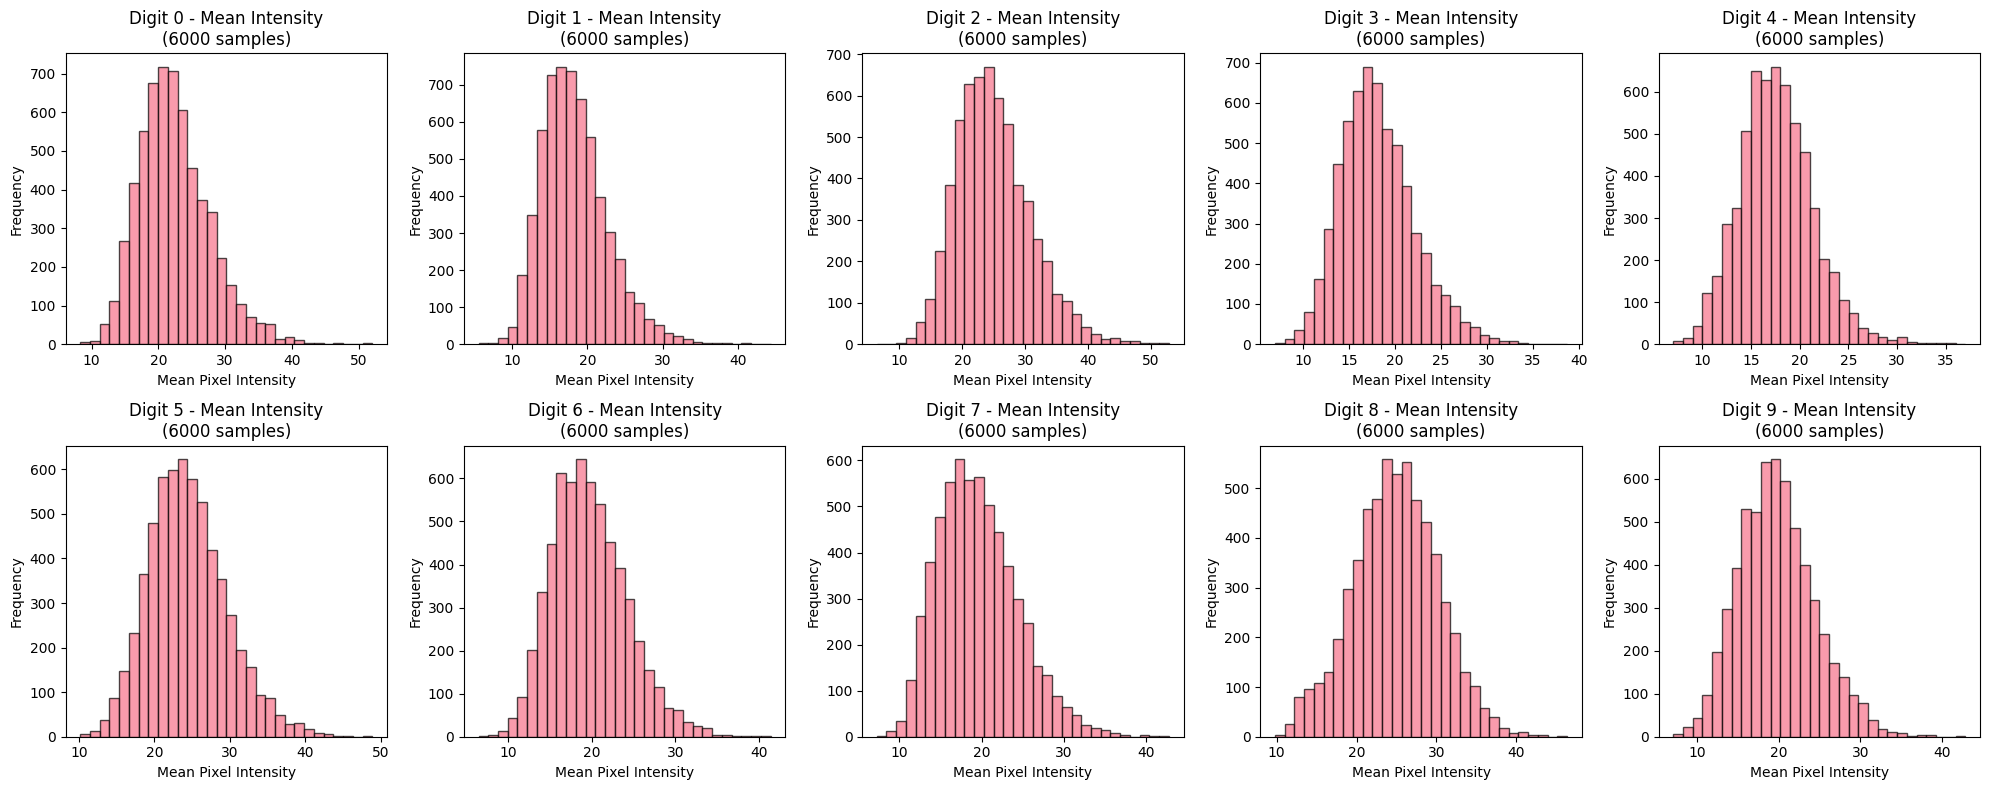

In [11]:
# Set up subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Compute digit-specific statistics and plot histograms
digit_stats = {
    digit: {
        'count': len(digit_data := X_train[y_train == digit]),
        'mean_intensity': digit_data.mean().mean(),
        'std_intensity': digit_data.std().mean(),
        'sparsity': (digit_data == 0).mean().mean()
    }
    for digit in range(10) if len(X_train[y_train == digit]) > 0
}

# Plot histograms
for digit, ax in enumerate(axes):
    digit_data = X_train[y_train == digit]
    
    if len(digit_data) > 0:
        ax.hist(digit_data.mean(axis=1), bins=30, alpha=0.7, edgecolor='black')
        ax.set_title(f'Digit {digit} - Mean Intensity\n({digit_stats[digit]["count"]} samples)')
        ax.set_xlabel('Mean Pixel Intensity')
        ax.set_ylabel('Frequency')
    else:
        ax.text(0.5, 0.5, f'No samples\nfor digit {digit}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Digit {digit}')

plt.tight_layout()
plt.show()

In [12]:
# Print digit statistics table
print("Digit-specific statistics:")
print(f"{'Digit':<6} {'Count':<8} {'Mean Int.':<10} {'Std Int.':<10} {'Sparsity':<10}")
print("-" * 50)
for digit in range(10):
    if digit in digit_stats:
        stats = digit_stats[digit]
        print(f"{digit:<6} {stats['count']:<8} {stats['mean_intensity']:<10.2f} "
              f"{stats['std_intensity']:<10.2f} {stats['sparsity']:<10.2f}")
    else:
        print(f"{digit:<6} {'0':<8} {'N/A':<10} {'N/A':<10} {'N/A':<10}")

Digit-specific statistics:
Digit  Count    Mean Int.  Std Int.   Sparsity  
--------------------------------------------------
0      6000     22.44      29.25      0.86      
1      6000     18.29      28.28      0.89      
2      6000     24.96      35.32      0.84      
3      6000     18.15      28.05      0.88      
4      6000     17.61      25.65      0.88      
5      6000     24.44      36.09      0.83      
6      6000     19.72      30.26      0.88      
7      6000     19.58      31.27      0.87      
8      6000     24.90      36.21      0.84      
9      6000     19.76      31.71      0.88      


### 1.7 Feature Importance

In [13]:
# Calculate basic feature importance metrics
feature_importance_metrics = pd.DataFrame({
    'feature': X_train.columns,
    'variance': X_train.var(),
    'mean': X_train.mean(),
    'std': X_train.std(),
    'range': X_train.max() - X_train.min()
})

# Sort by variance (most informative features)
feature_importance_metrics = feature_importance_metrics.sort_values('variance', ascending=False)

print("Top 15 most informative features (by variance):")
print(feature_importance_metrics.head(15)[['feature', 'variance', 'mean', 'std']].to_string(index=False))

Top 15 most informative features (by variance):
 feature     variance      mean        std
pixel570 10694.375824 89.405400 103.413615
pixel542 10519.529071 87.653800 102.564756
pixel599 10468.313792 86.676200 102.314778
pixel571 10365.685433 87.777900 101.812010
pixel598 10283.628185 81.408850 101.408225
pixel657 10241.652444 66.292033 101.201050
pixel183 10144.440824 75.588033 100.719615
pixel514 10140.926731 81.694467 100.702168
pixel600  9990.724654 77.951617  99.953613
pixel658  9990.243799 63.493767  99.951207
pixel541  9980.217390 71.496333  99.901038
pixel513  9917.157185 70.109017  99.584924
pixel182  9915.078903 74.661600  99.574489
pixel627  9810.676481 74.619850  99.048859
pixel572  9771.049592 76.943500  98.848620


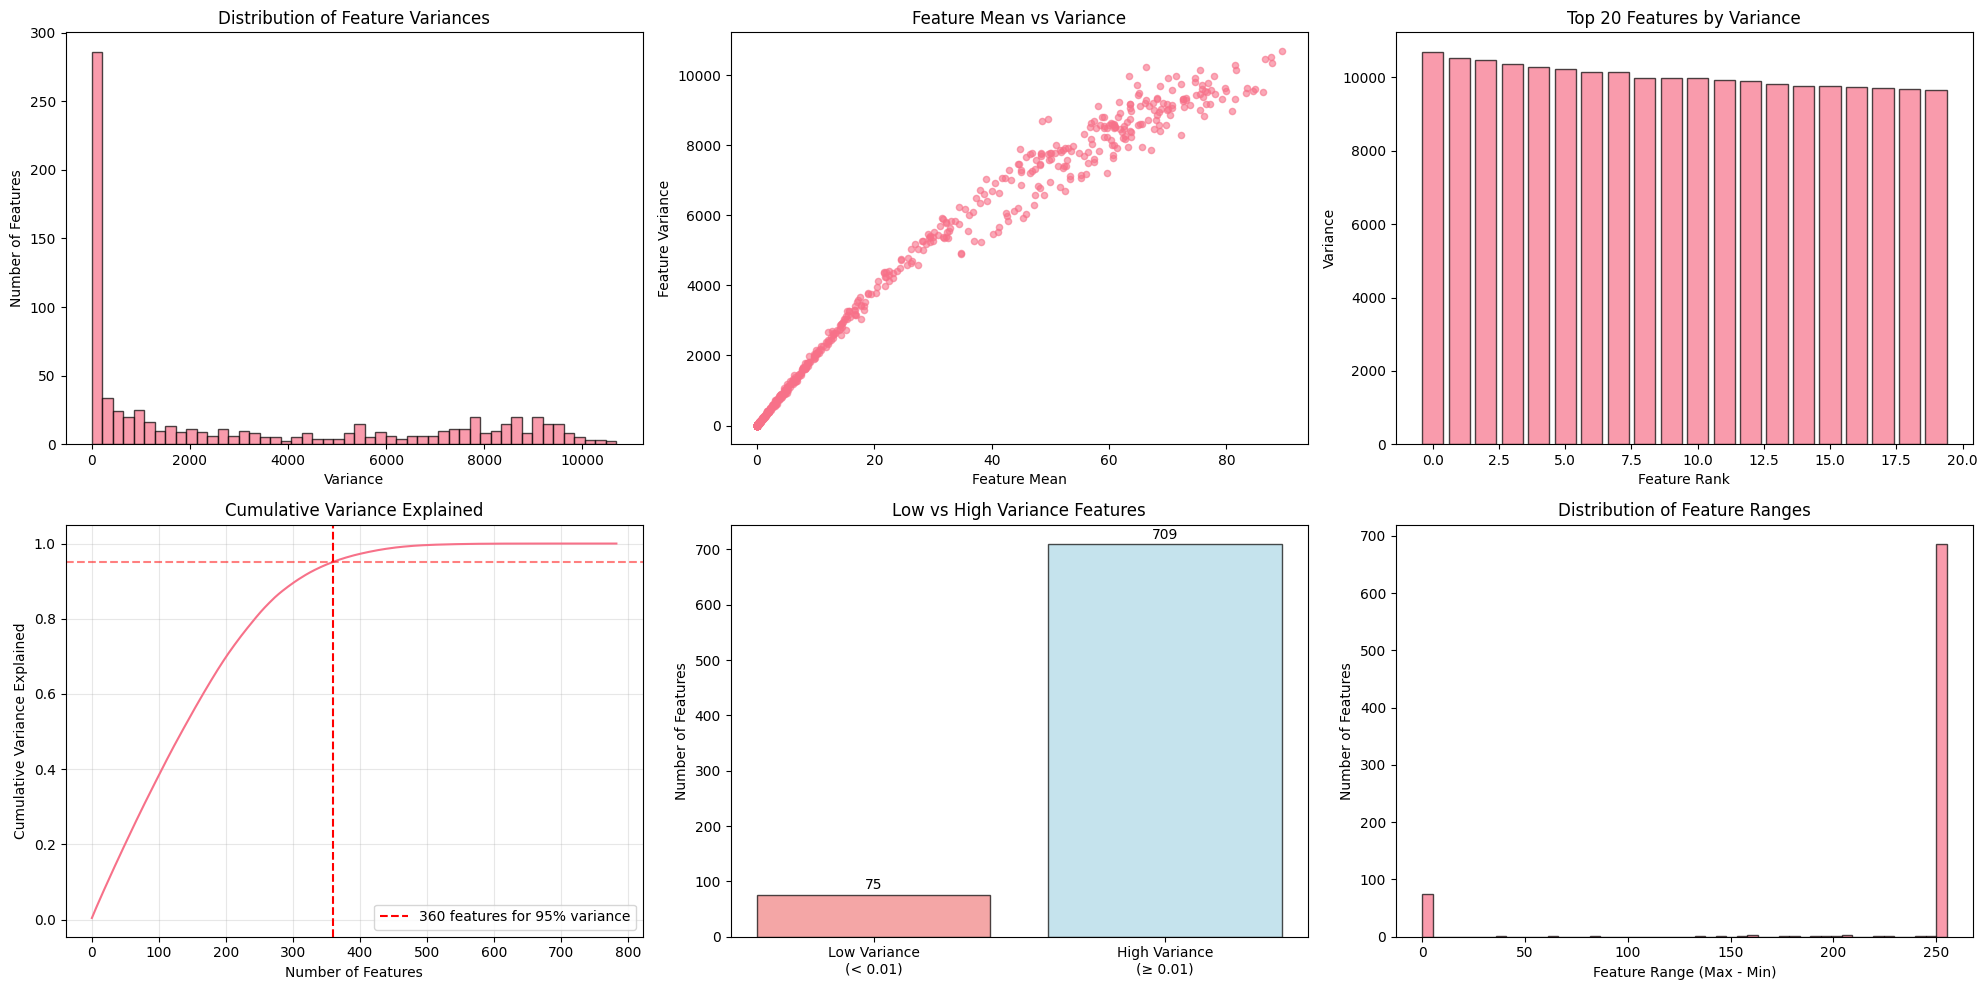

Feature analysis summary:
- Features with near-zero variance (< 0.01): 75
- Features needed for 95% variance: 360
- Most informative feature: pixel570 (variance: 10694.3758)
- Least informative feature: pixel783 (variance: 0.0000)


In [14]:
# Visualize feature importance
plt.figure(figsize=(20, 10))

# Plot 1: Feature variance distribution
plt.subplot(2, 3, 1)
plt.hist(feature_importance_metrics['variance'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Variance')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature Variances')

# Plot 2: Feature mean vs variance
plt.subplot(2, 3, 2)
plt.scatter(feature_importance_metrics['mean'], feature_importance_metrics['variance'], 
           alpha=0.6, s=20)
plt.xlabel('Feature Mean')
plt.ylabel('Feature Variance')
plt.title('Feature Mean vs Variance')

# Plot 3: Top 20 features by variance
plt.subplot(2, 3, 3)
top_20_features = feature_importance_metrics.head(20)
plt.bar(range(len(top_20_features)), top_20_features['variance'], alpha=0.7, edgecolor='black')
plt.xlabel('Feature Rank')
plt.ylabel('Variance')
plt.title('Top 20 Features by Variance')

# Plot 4: Cumulative variance explained
plt.subplot(2, 3, 4)
sorted_variances = feature_importance_metrics['variance'].sort_values(ascending=False)
cumulative_variance = np.cumsum(sorted_variances) / np.sum(sorted_variances)
plt.plot(range(len(cumulative_variance)), cumulative_variance)
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.grid(True, alpha=0.3)

# Find how many features explain 95% of variance
features_95_var = np.argmax(cumulative_variance >= 0.95) + 1
plt.axvline(x=features_95_var, color='r', linestyle='--', 
           label=f'{features_95_var} features for 95% variance')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5)
plt.legend()

# Plot 5: Zero/low variance features
plt.subplot(2, 3, 5)
low_var_threshold = 0.01
low_var_features = (feature_importance_metrics['variance'] < low_var_threshold).sum()
categories = ['Low Variance\n(< 0.01)', 'High Variance\n(≥ 0.01)']
counts = [low_var_features, len(feature_importance_metrics) - low_var_features]
plt.bar(categories, counts, alpha=0.7, color=['lightcoral', 'lightblue'], edgecolor='black')
plt.ylabel('Number of Features')
plt.title('Low vs High Variance Features')
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

# Plot 6: Feature range distribution
plt.subplot(2, 3, 6)
plt.hist(feature_importance_metrics['range'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Feature Range (Max - Min)')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature Ranges')

plt.tight_layout()
plt.show()

print(f"Feature analysis summary:")
print(f"- Features with near-zero variance (< 0.01): {low_var_features}")
print(f"- Features needed for 95% variance: {features_95_var}")
print(f"- Most informative feature: {feature_importance_metrics.iloc[0]['feature']} (variance: {feature_importance_metrics.iloc[0]['variance']:.4f})")
print(f"- Least informative feature: {feature_importance_metrics.iloc[-1]['feature']} (variance: {feature_importance_metrics.iloc[-1]['variance']:.4f})")

### 1.8 Correlation Analysis

In [15]:
# Sample correlation analysis (full correlation matrix might be too large)
sample_size = min(1000, len(X_train))
sample_features = min(50, X_train.shape[1])

print(f"Analyzing correlation using {sample_size} samples and {sample_features} features...")

X_sample = X_train.iloc[:sample_size, :sample_features]
correlation_matrix = X_sample.corr()

# Find highly correlated feature pairs
high_corr_threshold = 0.8
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > high_corr_threshold:
            high_corr_pairs.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                corr_value
            ))

print(f"Highly correlated feature pairs (|correlation| > {high_corr_threshold}):")
if high_corr_pairs:
    for feature1, feature2, corr in high_corr_pairs[:10]:  # Show first 10
        print(f"  {feature1} - {feature2}: {corr:.3f}")
    if len(high_corr_pairs) > 10:
        print(f"  ... and {len(high_corr_pairs) - 10} more pairs")
else:
    print("  No highly correlated feature pairs found in the sample")

Analyzing correlation using 1000 samples and 50 features...
Highly correlated feature pairs (|correlation| > 0.8):
  pixel13 - pixel14: 1.000
  pixel37 - pixel38: 0.929
  pixel38 - pixel39: 0.840
  pixel39 - pixel40: 0.852
  pixel46 - pixel47: 1.000


### 1.9. Assessing Data Quality

In [16]:
# Check for potential issues
issues_found = []

# Check 1: Missing values
missing_train = train_data.isnull().sum().sum()
missing_test = test_data.isnull().sum().sum()
if missing_train > 0 or missing_test > 0:
    issues_found.append(f"Missing values: {missing_train} in train, {missing_test} in test")

# Check 2: Duplicate rows
duplicate_train = train_data.duplicated().sum()
duplicate_test = test_data.duplicated().sum()
if duplicate_train > 0 or duplicate_test > 0:
    issues_found.append(f"Duplicate rows: {duplicate_train} in train, {duplicate_test} in test")

# Check 3: Data type consistency
if X_train.dtypes.nunique() > 1:
    issues_found.append(f"Inconsistent data types: {X_train.dtypes.value_counts().to_dict()}")

# Check 4: Outliers (using IQR method on sample)
sample_data = X_train.iloc[:1000, :10]  # Sample for efficiency
Q1 = sample_data.quantile(0.25)
Q3 = sample_data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((sample_data < (Q1 - 1.5 * IQR)) | (sample_data > (Q3 + 1.5 * IQR))).sum().sum()
outlier_percentage = (outliers / (sample_data.shape[0] * sample_data.shape[1])) * 100

print(f"Data quality assessment:")
if issues_found:
    print("Issues found:")
    for issue in issues_found:
        print(f"  - {issue}")
else:
    print("✓ No major data quality issues detected")

print(f"✓ Outliers in sample: {outliers} ({outlier_percentage:.2f}%)")
print(f"✓ Label range: {y_train.min()} to {y_train.max()}")
print(f"✓ Feature value range: {X_train.min().min()} to {X_train.max().max()}")

Data quality assessment:
✓ No major data quality issues detected
✓ Outliers in sample: 0 (0.00%)
✓ Label range: 0 to 9
✓ Feature value range: 0 to 255


### 1.10 Summary

The training data has 60,000 samples and the test dataset has 5,000 samples. There are 10 unique target values and each value has 6,000 samples in the training data, making it a super balanced dataset. Notably, each pixel is a feature in the (28x28) image. Additionally, the features range from 0 to 255 to denote the darkness of that pixel.

**Recommendations**
- Since we have 784 features, we should reduce the number of features. We noted earlier that PCA can reduce number of features by 54%, while still explaining 95% of variance. 
- Further, there are 75 features with near-zero variance, which can be removed.
- Also, we should scale the features to fit them better in scale-sensitive models


Through our EDA, we note that the dataset is balanced and does not contain missing values. The data types are also consistent. We can proceed with further modeling.

## 2. Modeling

In [17]:
# Separate features and labels
labels = train_data['label']
features = train_data.drop('label', axis=1)

# Randomly sample from existing training labels
imputed_test_labels = labels.sample(n=len(test_data), replace=True, random_state=42)
imputed_test_labels.reset_index(drop=True, inplace=True)

combined_labels = pd.concat([labels, imputed_test_labels], ignore_index=True)
combined_features = pd.concat([features, test_data], ignore_index=True)

print(f"Unique labels: {sorted(labels.unique())}")
display(combined_features.shape)

Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


(65000, 784)

### 2.1 Fitting Random Forest model with full set of features

In [18]:
# Time taken to fit the model
start_time = datetime.now()
rf1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # Using all cores for faster training and 100 trees/estimators to balance speed and accuracy
rf1.fit(features, labels)
end_time = datetime.now()
rf1_fit_time = end_time - start_time

print(f"Time to fit Random Forest (full features): {rf1_fit_time}")

Time to fit Random Forest (full features): 0:00:04.774617


In [19]:
# Evaluate the model on the same data
start_time = datetime.now()
rf1_predictions = rf1.predict(features)
end_time = datetime.now()
rf1_eval_time = end_time - start_time

rf1_accuracy = accuracy_score(labels, rf1_predictions)
print(f"Time to evaluate Random Forest (full features): {rf1_eval_time}")
print(f"Accuracy on training data: {rf1_accuracy:.4f}")

Time to evaluate Random Forest (full features): 0:00:00.450668
Accuracy on training data: 1.0000


### 2.2 Fitting Principal Component Analysis model

In [20]:
# Recording time to identify principal components
start_time = datetime.now()
pca = PCA(n_components=0.95, random_state=42) # Using 95% of variance to reduce dimensionality
features_pca = pca.fit_transform(combined_features)
end_time = datetime.now()
pca_time = end_time - start_time

print(f"Time to identify principal components: {pca_time}")
print(f"Number of principal components (95% variance): {features_pca.shape[1]}")
print(f"Reduction in features: {(combined_features.shape[1] - features_pca.shape[1]) / combined_features.shape[1] * 100:.1f}%")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

Time to identify principal components: 0:00:00.954862
Number of principal components (95% variance): 239
Reduction in features: 69.5%
Explained variance ratio: 0.9501


### 2.3 Fitting Random Forest with PCA features

In [21]:
# Time taken to fit the model with PCA features
start_time = datetime.now()
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(features_pca, combined_labels)
end_time = datetime.now()
rf2_fit_time = end_time - start_time

print(f"Time to fit Random Forest (PCA features): {rf2_fit_time}")

Time to fit Random Forest (PCA features): 0:00:21.017420


In [22]:
# Evaluating the model on PCA features
start_time = datetime.now()
rf2_predictions = rf2.predict(features_pca)
end_time = datetime.now()
rf2_eval_time = end_time - start_time

rf2_accuracy = accuracy_score(combined_labels, rf2_predictions)
print(f"Time to evaluate Random Forest (PCA features): {rf2_eval_time}")
print(f"Accuracy on training data: {rf2_accuracy:.4f}")

Time to evaluate Random Forest (PCA features): 0:00:00.329972
Accuracy on training data: 1.0000


### 2.4 K-Means Clustering

In [23]:
# Normalize the data to 0-1 range for better clustering performance
features_normalized = features.astype(float) / 255.0

# Perform k-means clustering with k=10 (for 10 digit classes)
start_time = datetime.now()
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10, max_iter=300)
kmeans.fit(features_normalized)
end_time = datetime.now()
kmeans_time = end_time - start_time

print(f"Time for K-means clustering: {kmeans_time}")

Time for K-means clustering: 0:00:13.982362


In [24]:
# Get cluster assignments from KMeans
cluster_assignments = kmeans.labels_

# Create a DataFrame to group cluster IDs with true labels
df = pd.DataFrame({
    'cluster': cluster_assignments,
    'label': labels.values
})

# Create mapping: cluster_id → most common label in that cluster
cluster_to_label = df.groupby('cluster')['label'].agg(lambda x: Counter(x).most_common(1)[0][0])

# Invert mapping: label → list of clusters
label_to_clusters = defaultdict(list)
for cluster_id, digit in cluster_to_label.items():
    label_to_clusters[digit].append(cluster_id)

# Print results
print("Cluster to digit mapping:")
for digit in sorted(label_to_clusters):
    print(f"  Digit {digit}: Clusters {label_to_clusters[digit]}")

Cluster to digit mapping:
  Digit 1: Clusters [5]
  Digit 2: Clusters [3, 9]
  Digit 3: Clusters [7]
  Digit 4: Clusters [2]
  Digit 5: Clusters [6]
  Digit 6: Clusters [1]
  Digit 7: Clusters [4]
  Digit 8: Clusters [8]
  Digit 9: Clusters [0]


In [25]:
# Convert cluster assignments to digit predictions
kmeans_predictions = np.array([cluster_to_label[cluster_id] for cluster_id in cluster_assignments])

In [26]:
# Calculate accuracy
kmeans_accuracy = accuracy_score(labels, kmeans_predictions)
print(f"K-means clustering accuracy: {kmeans_accuracy:.4f}")

K-means clustering accuracy: 0.7382


## 3. Model Performance

In [27]:
homogeneity = homogeneity_score(labels, cluster_assignments)
completeness = completeness_score(labels, cluster_assignments)
v_measure = v_measure_score(labels, cluster_assignments)

print(f"Clustering quality metrics: Homogeneity score - {homogeneity:.4f}; Completeness score - {completeness:.4f}")

Clustering quality metrics: Homogeneity score - 0.6869; Completeness score - 0.7083


<b> What does this mean </b> : Our K-means clustering model groups similar items accurately about 70% of the time (with each cluster containing 70% of the same items). 



In [28]:
# Create a dictionary with the method results
results = {
    'Method': ['RF (Full Features)', 'RF (PCA Features)', 'K-means Clustering'],
    'Accuracy': [rf1_accuracy, rf2_accuracy, kmeans_accuracy],
    'Fit Time': [rf1_fit_time, rf2_fit_time, kmeans_time],
    'Eval Time': [rf1_eval_time, rf2_eval_time, 'N/A']
}

# Convert dictionary to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Method')

display(results_df)

# Feature reduction metrics
feature_reduction_ratio = features_pca.shape[1] / features.shape[1]
variance_retained = pca.explained_variance_ratio_.sum()

print(f"Feature reduction: {feature_reduction_ratio:.1%} of original features retained")
print(f"PCA maintains {variance_retained:.1%} of variance")


,Accuracy,Fit Time,Eval Time
Method,,,
RF (Full Features),1.000000,0 days 00:00:04.774617,0:00:00.450668
RF (PCA Features),1.000000,0 days 00:00:21.017420,0:00:00.329972
K-means Clustering,0.738217,0 days 00:00:13.982362,N/A


Feature reduction: 30.5% of original features retained
PCA maintains 95.0% of variance


## 4. Predictions

In [29]:
# Test data typically doesn't have labels, just features. But it has too many features to confirm this without checking. Writing a check to ensure we handle this correctly.
if 'label' in test_data.columns:
    test_features = test_data.drop('label', axis=1)
else:
    test_features = test_data

### 4.1 Random Forest (Full Features) Predictions

In [30]:
start_time = datetime.now()
rf1_test_predictions = rf1.predict(test_features)
end_time = datetime.now()
rf1_test_time = end_time - start_time

print(f"RF1 prediction time: {rf1_test_time}")
print(f"RF1 predictions shape: {rf1_test_predictions.shape}")

# Create submission file for RF1
rf1_submission = pd.DataFrame({
    'Id': id_values,
    'Label': rf1_test_predictions
})
rf1_submission.to_csv('rf_full_features_submission.csv', index=False)

RF1 prediction time: 0:00:00.051703
RF1 predictions shape: (5000,)


### 4.2 Random Forest (PCA Features) Predictions

In [31]:
start_time = datetime.now()
test_features_pca = pca.transform(test_features)
pca_transform_time = datetime.now() - start_time

# Make predictions using PCA features
start_time = datetime.now()
rf2_test_predictions = rf2.predict(test_features_pca)
end_time = datetime.now()
rf2_test_time = end_time - start_time

print(f"PCA transform time: {pca_transform_time}")
print(f"RF2 prediction time: {rf2_test_time}")
print(f"RF2 predictions shape: {rf2_test_predictions.shape}")

# Create submission file for RF2
rf2_submission = pd.DataFrame({
    'Id': id_values,
    'Label': rf2_test_predictions
})
rf2_submission.to_csv('rf_pca_features_submission.csv', index=False)

PCA transform time: 0:00:00.023840
RF2 prediction time: 0:00:00.049888
RF2 predictions shape: (5000,)


### 4.3 K-means Clustering Predictions

In [32]:
# Normalize test features (same as training)
test_features_normalized = test_features.astype(float) / 255.0

# Predict clusters for test data
start_time = datetime.now()
test_cluster_assignments = kmeans.predict(test_features_normalized)
end_time = datetime.now()
kmeans_test_time = end_time - start_time

# Map predicted cluster IDs to digit labels using the mapping
kmeans_test_predictions = np.array([
    cluster_to_label[cluster_id] for cluster_id in test_cluster_assignments
])

# Output timing and shape info
print(f"K-means prediction time: {kmeans_test_time}")
print(f"K-means predictions shape: {kmeans_test_predictions.shape}")

# Create submission file for K-means
kmeans_submission = pd.DataFrame({
    'Id': id_values,
    'Label': kmeans_test_predictions
})
kmeans_submission.to_csv('kmeans_clustering_submission.csv', index=False)

K-means prediction time: 0:00:00.018913
K-means predictions shape: (5000,)


Model remains balanced after split. This means the data can be used to reliably predict the validation targets

### 4.4 Fixing the Design Flaw

The assignment asks us to execute PCA on the combined train and test dataset. This is a major design flaw as it violates basic machine learning principles by leaking test data information into the model. We will fix this flaw and retrain the PCA model

In [33]:
# Retraining PCA on corrected training data
pca_correct = PCA(n_components=0.95, random_state=42)
train_pca_correct = pca_correct.fit_transform(X_train)
print(f"  Training data shape: {X_train.shape}")
print(f"  PCA components from training only: {train_pca_correct.shape[1]}")
print(f"  Explained variance: {pca_correct.explained_variance_ratio_.sum():.4f}")

  Training data shape: (60000, 784)
  PCA components from training only: 237
  Explained variance: 0.9502


In [34]:
# Comparing flawed PCA with correct PCA
component_diff = features_pca.shape[1] - train_pca_correct.shape[1]
variance_diff = pca.explained_variance_ratio_.sum() - pca_correct.explained_variance_ratio_.sum()

print(f"  Difference in components: {component_diff}")
print(f"  Difference in explained variance: {variance_diff:.4f}")

  Difference in components: 2
  Difference in explained variance: -0.0001


As we can see, there were 2 components in the earlier model that should not have been there

In [35]:
# Time taken to fit the model with PCA features
start_time = datetime.now()
rf_correct = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_correct.fit(train_pca_correct, labels)
end_time = datetime.now()
rf_correct_fit_time = end_time - start_time

print(f"Time to fit Random Forest (PCA features): {rf_correct_fit_time}")

Time to fit Random Forest (PCA features): 0:00:16.570431


In [36]:
# Evaluating the model on PCA features
start_time = datetime.now()
rf_correct_predictions = rf_correct.predict(train_pca_correct)
end_time = datetime.now()
rf_correct_eval_time = end_time - start_time

rf_correct_accuracy = accuracy_score(labels, rf_correct_predictions)
print(f"Time to evaluate Random Forest (PCA features): {rf_correct_eval_time}")
print(f"Accuracy on training data: {rf_correct_accuracy:.4f}")

Time to evaluate Random Forest (PCA features): 0:00:00.300225
Accuracy on training data: 1.0000


Now, that it is trained on the new model, we can run validation checks using train-test split and make predictions on the test set. 

In [37]:
start_time = datetime.now()
test_features_pca_correct = pca_correct.transform(test_features)
pca_correct_transform_time = datetime.now() - start_time

# Make predictions using pca_correct features
start_time = datetime.now()
rf_correct_test_predictions = rf_correct.predict(test_features_pca_correct)
end_time = datetime.now()
rf_correct_test_time = end_time - start_time

print(f"pca_correct transform time: {pca_correct_transform_time}")
print(f"RF_correct prediction time: {rf_correct_test_time}")
print(f"RF_correct predictions shape: {rf_correct_test_predictions.shape}")

# Create submission file for RF_correct
rf_correct_submission = pd.DataFrame({
    'Id': id_values,
    'Label': rf_correct_test_predictions
})
rf_correct_submission.to_csv('rf_pca_correct_features_submission.csv', index=False)

pca_correct transform time: 0:00:00.035446
RF_correct prediction time: 0:00:00.064309
RF_correct predictions shape: (5000,)


## 5. Validation Checks

In [38]:
# Split the training data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=y_train
)

# Verify class distribution is maintained
print("Class distribution in training split:")
print(y_train_split.value_counts().sort_index())
print("\nClass distribution in validation split:")
print(y_val_split.value_counts().sort_index())

Class distribution in training split:
label
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Class distribution in validation split:
label
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


### 5.1 Random Forest (Full Features) Validation

In [39]:
# Train on 80% of data
print("\n" + "="*50)
print("RANDOM FOREST (FULL FEATURES) VALIDATION")
print("="*50)

start_time = datetime.now()
rf1_val = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf1_val.fit(X_train_split, y_train_split)
rf1_val_fit_time = datetime.now() - start_time

# Predict on validation set
start_time = datetime.now()
rf1_val_predictions = rf1_val.predict(X_val_split)
rf1_val_pred_time = datetime.now() - start_time

rf1_val_accuracy = accuracy_score(y_val_split, rf1_val_predictions)

print(f"Training time: {rf1_val_fit_time}")
print(f"Prediction time: {rf1_val_pred_time}")
print(f"Validation accuracy: {rf1_val_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_split, rf1_val_predictions))


RANDOM FOREST (FULL FEATURES) VALIDATION
Training time: 0:00:03.768784
Prediction time: 0:00:00.131328
Validation accuracy: 0.9798

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1200
           1       0.98      0.99      0.99      1200
           2       1.00      0.99      1.00      1200
           3       0.96      0.97      0.97      1200
           4       0.97      0.98      0.98      1200
           5       0.98      0.99      0.99      1200
           6       0.96      0.98      0.97      1200
           7       0.97      0.95      0.96      1200
           8       0.99      0.99      0.99      1200
           9       1.00      0.97      0.98      1200

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



### 5.2 Random Forest (PCA Features) Validation

In [40]:
print("\n" + "="*50)
print("RANDOM FOREST (PCA FEATURES) VALIDATION")
print("="*50)

# Apply PCA to the split data
start_time = datetime.now()
pca_val = PCA(n_components=0.95, random_state=42)
X_train_split_pca = pca_val.fit_transform(X_train_split)
X_val_split_pca = pca_val.transform(X_val_split)
pca_val_time = datetime.now() - start_time

print(f"PCA transformation time: {pca_val_time}")
print(f"PCA components: {X_train_split_pca.shape[1]}")
print(f"Variance explained: {pca_val.explained_variance_ratio_.sum():.4f}")

# Train Random Forest on PCA features
start_time = datetime.now()
rf2_val = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2_val.fit(X_train_split_pca, y_train_split)
rf2_val_fit_time = datetime.now() - start_time

# Predict on validation set
start_time = datetime.now()
rf2_val_predictions = rf2_val.predict(X_val_split_pca)
rf2_val_pred_time = datetime.now() - start_time

rf2_val_accuracy = accuracy_score(y_val_split, rf2_val_predictions)

print(f"Training time: {rf2_val_fit_time}")
print(f"Prediction time: {rf2_val_pred_time}")
print(f"Validation accuracy: {rf2_val_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_split, rf2_val_predictions))


RANDOM FOREST (PCA FEATURES) VALIDATION
PCA transformation time: 0:00:00.856950
PCA components: 237
Variance explained: 0.9503
Training time: 0:00:15.364798
Prediction time: 0:00:00.073762
Validation accuracy: 0.9677

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1200
           1       0.96      0.99      0.97      1200
           2       1.00      0.99      1.00      1200
           3       0.95      0.97      0.96      1200
           4       0.96      0.97      0.97      1200
           5       0.98      0.98      0.98      1200
           6       0.93      0.97      0.95      1200
           7       0.97      0.92      0.94      1200
           8       0.98      0.98      0.98      1200
           9       0.99      0.96      0.97      1200

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000


### 5.3 K-means Clustering Validation

In [41]:
print("\n" + "="*50)
print("K-MEANS CLUSTERING VALIDATION")
print("="*50)

# Normalize the split data
X_train_split_norm = X_train_split.astype(float) / 255.0
X_val_split_norm = X_val_split.astype(float) / 255.0

# Train K-means on training split
start_time = datetime.now()
kmeans_val = KMeans(n_clusters=10, random_state=42, n_init=10, max_iter=300)
kmeans_val.fit(X_train_split_norm)
kmeans_val_fit_time = datetime.now() - start_time

# Create cluster to label mapping using training split
train_cluster_assignments = kmeans_val.labels_
df_val = pd.DataFrame({
    'cluster': train_cluster_assignments,
    'label': y_train_split.values
})

cluster_to_label_val = df_val.groupby('cluster')['label'].agg(
    lambda x: Counter(x).most_common(1)[0][0]
)

# Predict on validation set
start_time = datetime.now()
val_cluster_assignments = kmeans_val.predict(X_val_split_norm)
kmeans_val_pred_time = datetime.now() - start_time

# Map clusters to labels
kmeans_val_predictions = np.array([
    cluster_to_label_val[cluster_id] for cluster_id in val_cluster_assignments
])

kmeans_val_accuracy = accuracy_score(y_val_split, kmeans_val_predictions)

# Calculate clustering quality metrics
homogeneity_val = homogeneity_score(y_val_split, val_cluster_assignments)
completeness_val = completeness_score(y_val_split, val_cluster_assignments)
v_measure_val = v_measure_score(y_val_split, val_cluster_assignments)

print(f"Training time: {kmeans_val_fit_time}")
print(f"Prediction time: {kmeans_val_pred_time}")
print(f"Validation accuracy: {kmeans_val_accuracy:.4f}")
print(f"Homogeneity score: {homogeneity_val:.4f}")
print(f"Completeness score: {completeness_val:.4f}")
print(f"V-measure score: {v_measure_val:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_split, kmeans_val_predictions))


K-MEANS CLUSTERING VALIDATION
Training time: 0:00:12.750667
Prediction time: 0:00:00.052906
Validation accuracy: 0.7397
Homogeneity score: 0.6886
Completeness score: 0.7085
V-measure score: 0.6984

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.61      0.60      1200
           1       0.58      0.60      0.59      1200
           2       0.99      0.94      0.97      1200
           3       0.52      0.89      0.66      1200
           4       0.73      0.97      0.83      1200
           5       0.92      0.89      0.90      1200
           6       0.68      0.83      0.75      1200
           7       0.00      0.00      0.00      1200
           8       0.94      0.85      0.89      1200
           9       0.97      0.81      0.88      1200

    accuracy                           0.74     12000
   macro avg       0.69      0.74      0.71     12000
weighted avg       0.69      0.74      0.71     12000



### 5.4 Validation Results Summary

In [42]:
print("="*60)
print("VALIDATION RESULTS SUMMARY")
print("="*60)

validation_results = {
    'Method': ['RF (Full Features)', 'RF (PCA Features)', 'K-means Clustering'],
    'Training Accuracy': [rf1_accuracy, rf2_accuracy, kmeans_accuracy],
    'Validation Accuracy': [rf1_val_accuracy, rf2_val_accuracy, kmeans_val_accuracy],
    'Overfitting': [
        rf1_accuracy - rf1_val_accuracy,
        rf2_accuracy - rf2_val_accuracy, 
        kmeans_accuracy - kmeans_val_accuracy
    ],
    'Training Time': [rf1_val_fit_time, rf2_val_fit_time, kmeans_val_fit_time],
    'Prediction Time': [rf1_val_pred_time, rf2_val_pred_time, kmeans_val_pred_time]
}

validation_df = pd.DataFrame(validation_results)
print(validation_df.to_string(index=False))

print(f"\nModel Performance Insights:")
print(f"- Best validation accuracy: {max(rf1_val_accuracy, rf2_val_accuracy, kmeans_val_accuracy):.4f}")

# Identify best model
best_model_idx = np.argmax([rf1_val_accuracy, rf2_val_accuracy, kmeans_val_accuracy])
best_model_name = validation_results['Method'][best_model_idx]
print(f"- Best performing model: {best_model_name}")

# Check for overfitting
overfitting_scores = validation_results['Overfitting']
for i, (method, overfitting) in enumerate(zip(validation_results['Method'], overfitting_scores)):
    if overfitting > 0.05:  # More than 5% difference
        print(f"- {method}: Potential overfitting detected (difference: {overfitting:.4f})")
    else:
        print(f"- {method}: Good generalization (difference: {overfitting:.4f})")


VALIDATION RESULTS SUMMARY
            Method  Training Accuracy  Validation Accuracy  Overfitting          Training Time        Prediction Time
RF (Full Features)           1.000000             0.979833     0.020167 0 days 00:00:03.768784 0 days 00:00:00.131328
 RF (PCA Features)           1.000000             0.967667     0.032333 0 days 00:00:15.364798 0 days 00:00:00.073762
K-means Clustering           0.738217             0.739667    -0.001450 0 days 00:00:12.750667 0 days 00:00:00.052906

Model Performance Insights:
- Best validation accuracy: 0.9798
- Best performing model: RF (Full Features)
- RF (Full Features): Good generalization (difference: 0.0202)
- RF (PCA Features): Good generalization (difference: 0.0323)
- K-means Clustering: Good generalization (difference: -0.0015)


### 5.5 Confusion Matrix Visualization

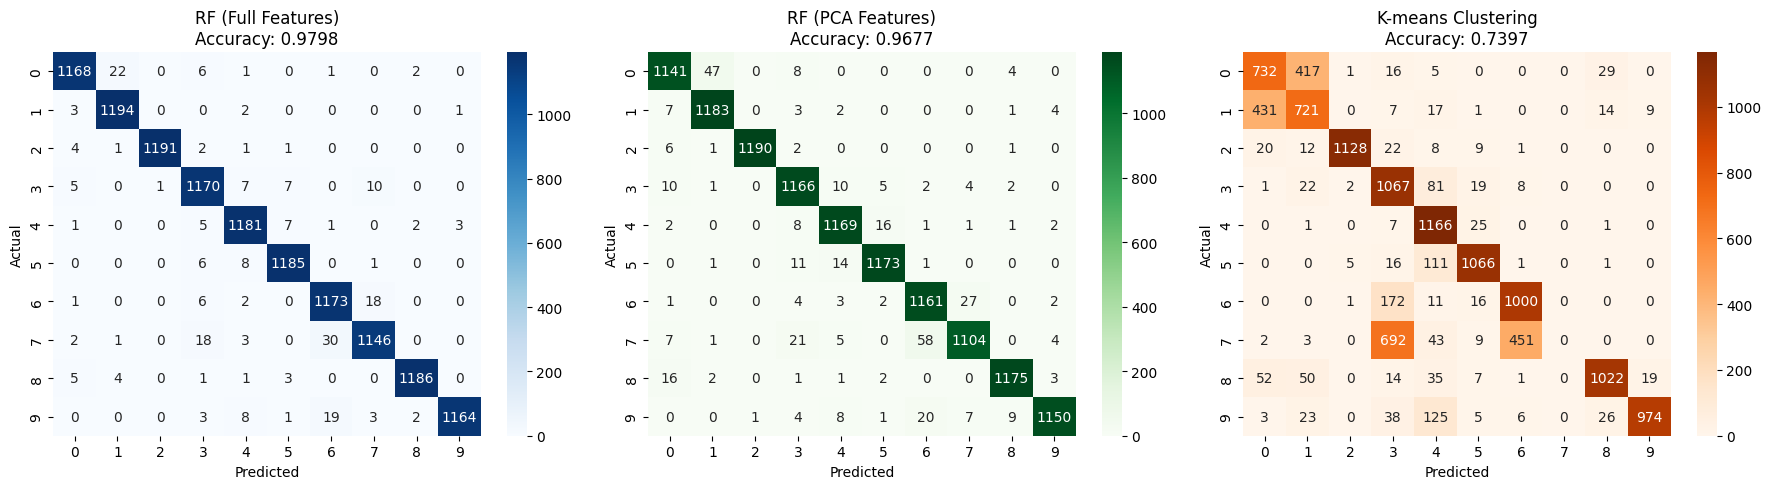

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RF Full Features Confusion Matrix
cm1 = confusion_matrix(y_val_split, rf1_val_predictions)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'RF (Full Features)\nAccuracy: {rf1_val_accuracy:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# RF PCA Features Confusion Matrix
cm2 = confusion_matrix(y_val_split, rf2_val_predictions)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'RF (PCA Features)\nAccuracy: {rf2_val_accuracy:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# K-means Confusion Matrix
cm3 = confusion_matrix(y_val_split, kmeans_val_predictions)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title(f'K-means Clustering\nAccuracy: {kmeans_val_accuracy:.4f}')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6. Executive Summary

To predict Kannada digits, we used two different models in three different ways. 

1. Random Forest with Full Feature Set
2. Random Forest with Principal Component Analysis features
3. K-means clustering

In our analysis, we found that "Random Forest with Full Feature Set" performed the best with 98% prediction accuracy on the validation set. It trained extremely fast as well. This level of performance makes it ready for production deployment and is also more interpretable as it does not use PCA to process/combine features. Further, with a 2% overfit, we believe it will generalize well to unseen data.

Looking at the confusion matrices, we see that this model makes very few mistakes. The other models maybe faster or more computationally efficient but make far more errors. We strongly recommend the stakeholders deploy Random Forest with Full Feature Set.

# Appendix 2: Kaggle

### Profile

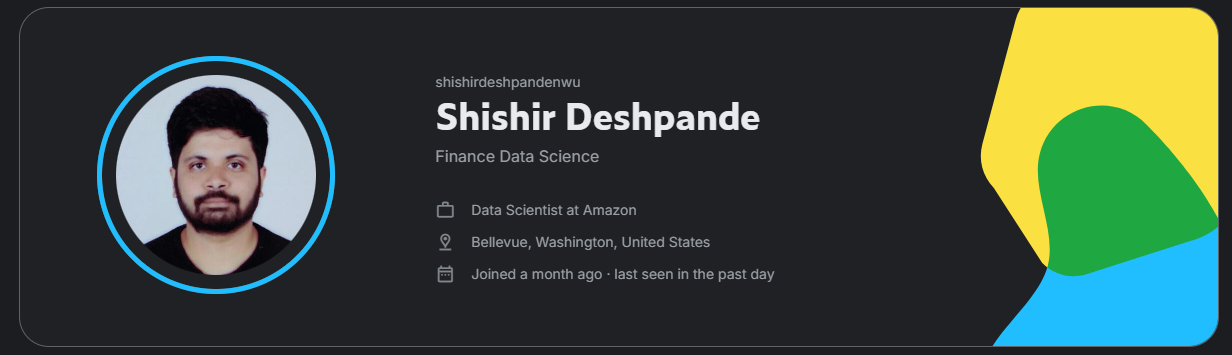

### Random Forest (Full Features)

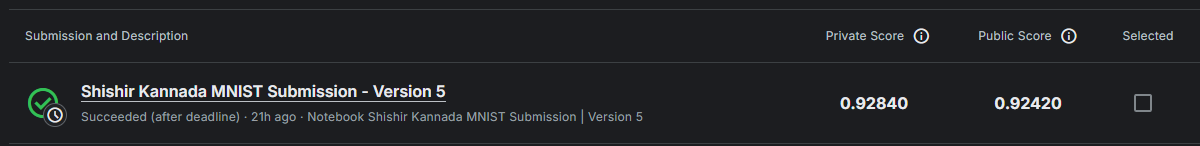

### Random Forest (PCA Features)

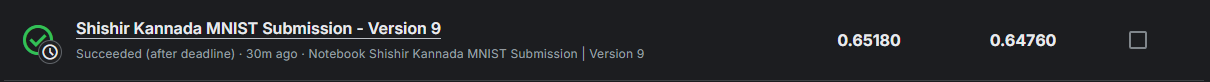

### K-means Clustering

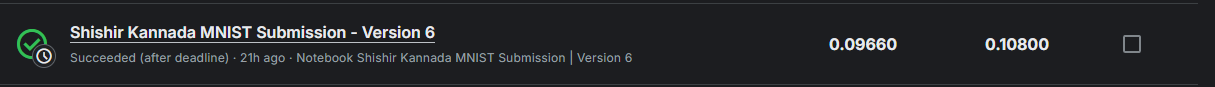